In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_kyiv_encoded = pd.read_csv('Kyiv_ML.csv')

X = df_kyiv_encoded.drop(columns=['price', 'Unnamed: 0'])
y = df_kyiv_encoded['price']

X['living_ratio'] = X['living_area'] / X['area']

X['is_low_floor'] = 0
X['is_high_floor'] = 0
X['is_middle_floor'] = 0

high_building_mask = X['floors_in_house'] > 6

X.loc[high_building_mask & (X['floor'] <= 3), 'is_low_floor'] = 1
X.loc[high_building_mask & (X['floor'] > (X['floors_in_house'] - 3)), 'is_high_floor'] = 1
X.loc[high_building_mask & (X['floor'] > 3) & (X['floor'] <= (X['floors_in_house'] - 3)), 'is_middle_floor'] = 1

low_building_mask = X['floors_in_house'] <= 6

X.loc[low_building_mask & (X['floor'] == 1), 'is_low_floor'] = 1
X.loc[low_building_mask & (X['floor'] == X['floors_in_house']), 'is_high_floor'] = 1
X.loc[low_building_mask & (X['floor'] > 1) & (X['floor'] < X['floors_in_house']), 'is_middle_floor'] = 1


X['is_historic_or_stalinka'] = (X['year_of_building'] < 1956).astype(int)
X['is_khrushchev'] = ((X['floors_in_house'] <= 5) & (X['year_of_building'] >= 1956) & (X['year_of_building'] <= 1980)).astype(int)
X['is_soviet_panel'] = ((X['floors_in_house'] > 5) & (X['floors_in_house'] <= 16) & (X['year_of_building'] >= 1970) & (X['year_of_building'] <= 1995)).astype(int)
X['is_modern_fund'] = ((X['year_of_building'] >= 2010) | (X['floors_in_house'] > 16)).astype(int)
X

,num_of_rooms,area,living_area,kitchen_area,floor,floors_in_house,year_of_building,district_Desnianskyi,district_Dniprovskyi,district_Holosiivskyi,...,district_Sviatoshynskyi,freshly_renovated_True,living_ratio,is_low_floor,is_high_floor,is_middle_floor,is_historic_or_stalinka,is_khrushchev,is_soviet_panel,is_modern_fund
0,2,92.00,56.00,17.0,19,25,2008,0,0,1,...,0,1,0.608696,0,0,1,0,0,0,1
1,2,52.30,30.00,8.0,8,9,1982,0,0,1,...,0,1,0.573614,0,1,0,0,0,1,0
2,2,64.00,32.00,15.0,16,22,2013,0,0,1,...,0,1,0.500000,0,0,1,0,0,0,1
3,1,49.00,20.00,10.0,11,23,2023,0,0,1,...,0,1,0.408163,0,0,1,0,0,0,1
4,1,41.00,14.00,19.0,5,21,2025,0,0,1,...,0,1,0.341463,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12021,2,67.00,27.99,12.0,9,17,2024,0,0,0,...,0,0,0.417761,0,0,1,0,0,0,1
12022,2,59.00,32.72,12.0,11,24,2014,0,0,0,...,0,0,0.554576,0,0,1,0,0,0,1
12023,2,81.65,31.55,40.0,23,24,2011,0,0,0,...,0,1,0.386405,0,1,0,0,0,0,1
12024,2,46.00,29.79,8.0,2,5,1966,0,0,0,...,0,1,0.647609,0,0,1,0,1,0,0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальної вибірки: {X_train.shape[0]} квартир")
print(f"Розмір тестової вибірки: {X_test.shape[0]} квартир")

Розмір навчальної вибірки: 9620 квартир
Розмір тестової вибірки: 2406 квартир


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}

results_list = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results_list.append({
        "Модель": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })

df_results = pd.DataFrame(results_list)

df_results = df_results.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("\n ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ:")
print(df_results)


 ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ:
             Модель  R2 Score  MAE ($)  RMSE ($)
0          LightGBM    0.6752   308.10    420.65
1          CatBoost    0.6735   309.05    421.75
2     Random Forest    0.6629   310.43    428.52
3  Ridge Regression    0.5442   380.90    498.29


In [4]:
from sklearn.model_selection import GridSearchCV


lgbm = LGBMRegressor(random_state=42, verbose=-1)

param_grid = {
    'n_estimators': [100, 200, 300, 500],    
    'learning_rate': [0.01, 0.03, 0.05, 0.1], 
    'max_depth': [4, 6, 8, -1], 
    'num_leaves': [15, 31, 63]
}

print("⏳ Запуск GridSearchCV для LightGBM... Це може зайняти 1-2 хвилини.")

grid_search = GridSearchCV(
    estimator=lgbm, 
    param_grid=param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1     
)

grid_search.fit(X_train, y_train)

best_lgbm_model = grid_search.best_estimator_

print("\n🏆 НАЙКРАЩІ ПАРАМЕТРИ ДЛЯ LIGHTGBM:")
print(grid_search.best_params_)

y_pred = best_lgbm_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n📊 МЕТРИКИ ОПТИМІЗОВАНОЇ МОДЕЛІ НА ТЕСТІ:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f} $")
print(f"RMSE: {rmse:.2f} $")

⏳ Запуск GridSearchCV для LightGBM... Це може зайняти 1-2 хвилини.

🏆 НАЙКРАЩІ ПАРАМЕТРИ ДЛЯ LIGHTGBM:
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 63}

📊 МЕТРИКИ ОПТИМІЗОВАНОЇ МОДЕЛІ НА ТЕСТІ:
R2 Score: 0.6766
MAE: 306.64 $
RMSE: 419.71 $


In [5]:
best_lgbm_model.booster_.save_model("optimized_lightgbm_kyiv_model.txt")
print("🎉 Оптимізовану модель LightGBM для Києва збережено!")

🎉 Оптимізовану модель LightGBM для Києва збережено!


=== Оптимізація Ridge (L2)... ===
=== Оптимізація Lasso (L1)... ===

=== 📊 РЕЗУЛЬТАТИ РЕГУЛЯРИЗАЦІЇ ===
Ridge L2 -> Найкращий alpha: 31.6228 | R2: 0.5442 | MAE: $380.96
Lasso L1 -> Найкращий alpha: 1.0000 | R2: 0.5441 | MAE: $381.05


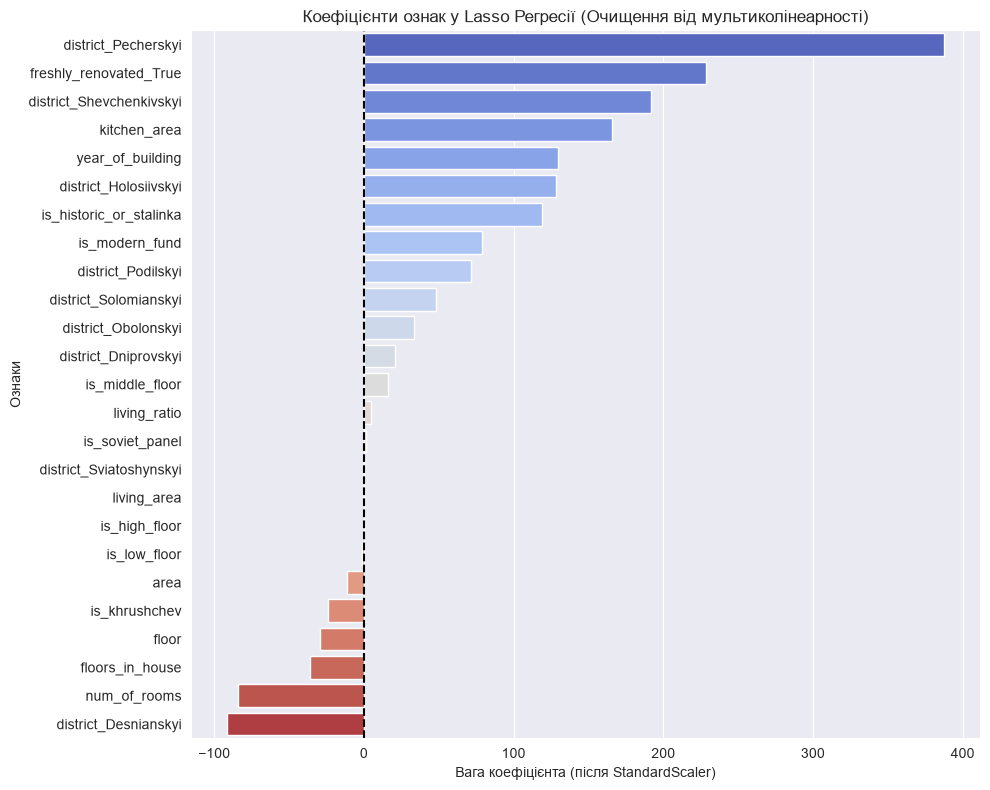


❌ Ознаки, які Lasso повністю занулила (видалила через надлишковість): ['district_Sviatoshynskyi', 'living_area', 'is_high_floor']


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ==========================================
# 1. СТВОРЕННЯ ПАЙПЛАЙНІВ З МАСШТАБУВАННЯМ
# ==========================================

# Налаштовуємо сітку для параметра alpha (сила регуляризації)
param_grid = {'model__alpha': np.logspace(-3, 3, 13)}

# Пайплайн для Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

# Пайплайн для Lasso
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=10000)) # збільшено max_iter для збіжності
])

# ==========================================
# 2. ЗАПУСК GRID SEARCH ДЛЯ ОБОХ МОДЕЛЕЙ
# ==========================================

print("=== Оптимізація Ridge (L2)... ===")
ridge_grid = GridSearchCV(ridge_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print("=== Оптимізація Lasso (L1)... ===")
lasso_grid = GridSearchCV(lasso_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

# ==========================================
# 3. ОЦІНКА ТА ПОРІВНЯННЯ МЕТРИК
# ==========================================

ridge_preds = ridge_grid.predict(X_test)
lasso_preds = lasso_grid.predict(X_test)

print("\n=== 📊 РЕЗУЛЬТАТИ РЕГУЛЯРИЗАЦІЇ ===")
print(f"Ridge L2 -> Найкращий alpha: {ridge_grid.best_params_['model__alpha']:.4f} | R2: {r2_score(y_test, ridge_preds):.4f} | MAE: ${mean_absolute_error(y_test, ridge_preds):.2f}")
print(f"Lasso L1 -> Найкращий alpha: {lasso_grid.best_params_['model__alpha']:.4f} | R2: {r2_score(y_test, lasso_preds):.4f} | MAE: ${mean_absolute_error(y_test, lasso_preds):.2f}")

# ==========================================
# 4. ВІЗУАЛІЗАЦІЯ КОЕФІЦІЄНТІВ LASSO (ЯК ВОНА ЗАHУЛЯЄ ФІЧІ)
# ==========================================

best_lasso = lasso_grid.best_estimator_.named_steps['model']
lasso_coefs = pd.Series(best_lasso.coef_, index=X_train.columns).sort_values(ascending=False)

# Фільтруємо, щоб побачити тільки ненульові або топ-15 вагомих ознак
plt.figure(figsize=(10, 8))
sns.barplot(x=lasso_coefs.values, y=lasso_coefs.index, hue=lasso_coefs.index, palette="coolwarm", legend=False)
plt.title("Коефіцієнти ознак у Lasso Регресії (Очищення від мультиколінеарності)")
plt.xlabel("Вага коефіцієнта (після StandardScaler)")
plt.ylabel("Ознаки")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Виведемо список ознак, які Lasso повністю занулила
zeroed_features = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f"\n❌ Ознаки, які Lasso повністю занулила (видалила через надлишковість): {zeroed_features}")